<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/Decision_Trees_vs_Random_Forest_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🌳 Decision Tree**

Think of a Decision Tree as a flowchart that works like a game of "20 Questions." It is a supervised learning algorithm used for both classification (assigning a label) and regression (predicting a number).



The model makes decisions by splitting the data into branches based on feature values until it reaches a final prediction.

📚  **Dataset**: Heart Disease UCI dataset
> **Goal**: Learn tree-based models from scratch, understand their internals, and master Random Forests
**

**Q. How the Tree "Decides" Where to Split
The tree doesn't just pick features at random. It uses mathematical formulas to find the split that creates the most "pure" groups (groups where most items belong to the same category).**


**Ans:**

**Gini Impurity**: Measures how often a randomly chosen element would be incorrectly labeled. A Gini score of 0 means the node is "pure" (all items are the same).

**Entropy** : Information Gain: Measures the "disorder" or randomness in the data. The tree chooses the split that reduces entropy the most.

The tree uses **impurity measures** to find the best split:

#### 1. Gini Impurity
Measures how often a randomly chosen element would be incorrectly labeled.

$$\text{Gini} = 1 - \sum_{i=1}^{n} p_i^2$$

- Gini = **0** → Pure node (all same class) ✅
- Gini = **0.5** → Maximum impurity (50/50 split) ❌

#### 2. Entropy (Information Gain)
Measures the disorder or uncertainty in the data.

$$\text{Entropy} = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

The tree picks the split that gives the **highest Information Gain** (= reduces entropy the most).

# ⚖️ **Practical Comparison**

| Criterion | Speed  | Accuracy                      | When to Prefer        |
| --------- | ------ | ----------------------------- | --------------------- |
| Gini      | Fast   | Very good                     | Default choice        |
| Entropy   | Medium | Slightly better in some cases | Interpretability      |
| Log Loss  | Medium | Similar to entropy            | Probabilistic outputs |




---



---

***Import*** libraries

In [24]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# import warnings
# warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")

All libraries imported successfully!


In [25]:
#load dataset
df=pd.read_csv('https://raw.githubusercontent.com/themehmi/datasets/refs/heads/main/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [29]:
#data preprocessing
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# We set max_depth=3 to prevent overfitting and keep it explainable
model = DecisionTreeClassifier(criterion='gini', max_depth=8, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

In [30]:
# Assuming 'model' is your DecisionTreeClassifier
# X_train, y_train: data the model SAW during training
# X_test, y_test: data the model has NEVER seen

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")

# Quick Overfitting Check
gap = train_acc - test_acc
print(f"Accuracy Gap: {gap:.2%}")

Training Accuracy: 99.02%
Testing Accuracy: 97.56%
Accuracy Gap: 1.46%


**Why 100% Train Accuracy is a Red Flag?**

**If you see 100% Training Accuracy, your Decision Tree has likely created a unique "leaf" for almost every single patient in your dataset. It’s no longer a model; it’s a lookup table. This is exactly where your Explainable ML toolkit comes in—it should show that the "Gradients" or "Splits" have become too specific to outliers.**

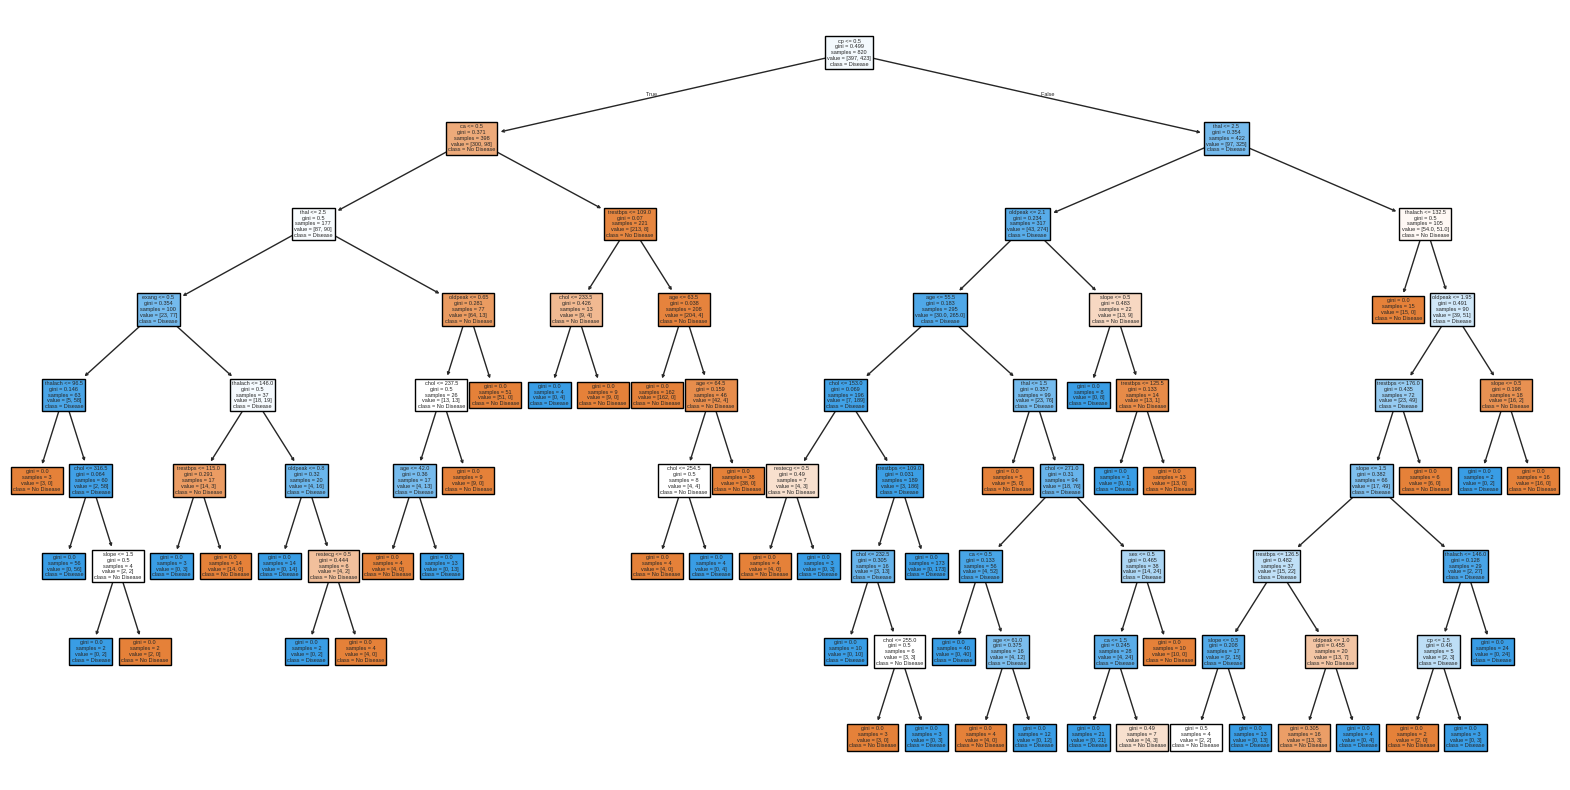

In [28]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.show()

How to Read the Visualization:

* **Top Node (Root):** This is the most "important" feature the model found (usually cp or thal for heart disease).

* **Colors:** The deeper the color, the more "pure" the node is. (e.g., Dark blue might mean 100% of patients in that box have heart disease).

* **Samples:** Shows how many patients from your training set fell into that specific branch.

**Confusion Matrix**

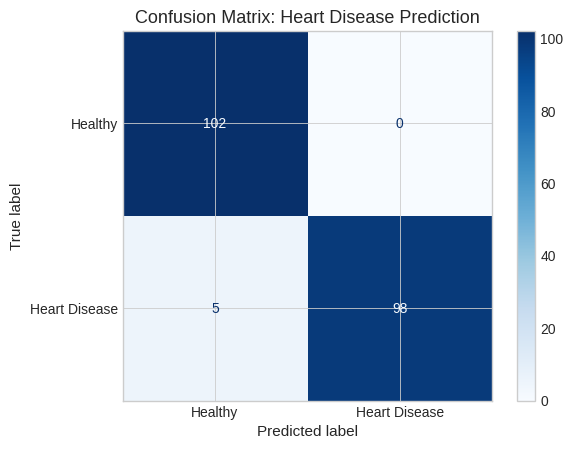

               precision    recall  f1-score   support

      Healthy       0.95      1.00      0.98       102
Heart Disease       1.00      0.95      0.98       103

     accuracy                           0.98       205
    macro avg       0.98      0.98      0.98       205
 weighted avg       0.98      0.98      0.98       205



In [34]:
# 1. Get predictions from your model
y_pred = model.predict(X_test)

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it beautifully
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Heart Disease'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix: Heart Disease Prediction")
plt.show()

report = classification_report(y_test, y_pred, target_names=['Healthy', 'Heart Disease'])
print(report)


---
## ⚠️ Part 2: Overfitting in Decision Trees

### The Problem
A Decision Tree can grow **very deep** and memorize the training data — this is called **overfitting**.

- **Overfitting:** Model performs great on training data but poorly on new data
- **Underfitting:** Model is too simple and fails on both training and test data
- **Just right (Goldilocks zone):** Good generalization!

### Solutions (Hyperparameters)

| Hyperparameter | What it does |
|---|---|
| `max_depth` | Limits how deep the tree can grow |
| `min_samples_split` | Minimum samples needed to split a node |
| `min_samples_leaf` | Minimum samples required in a leaf |
| `max_features` | Number of features to consider at each split |

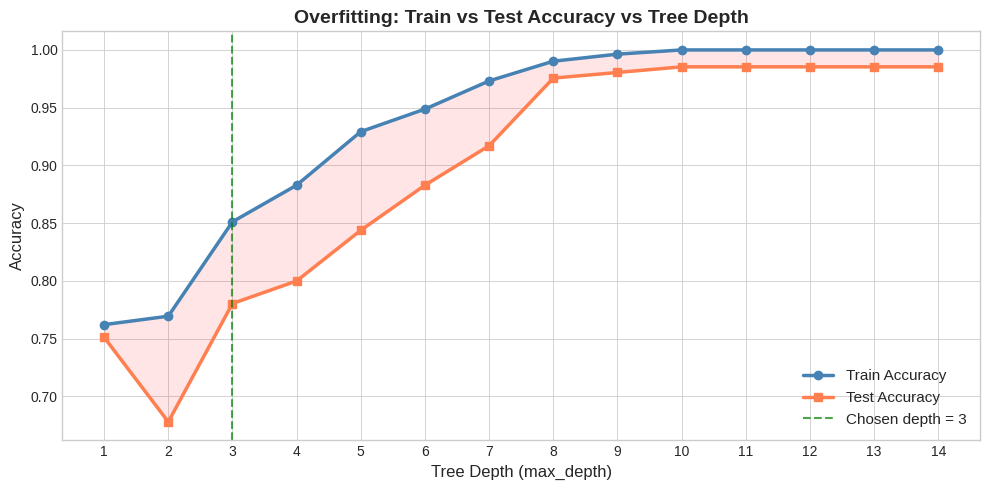

Notice: As depth increases, train accuracy → 100%, but test accuracy plateaus or drops.
   This gap = OVERFITTING. Keep max_depth small for better generalization!


In [35]:
# Visualizing Overfitting vs Underfitting
depths = range(1, 15)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'o-', label='Train Accuracy', color='steelblue', linewidth=2.5)
ax.plot(depths, test_accs,  's-', label='Test Accuracy',  color='coral',     linewidth=2.5)
ax.axvline(3, color='green', linestyle='--', alpha=0.7, label='Chosen depth = 3')
ax.fill_between(depths, train_accs, test_accs, alpha=0.1, color='red')
ax.set_xlabel('Tree Depth (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting: Train vs Test Accuracy vs Tree Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print("Notice: As depth increases, train accuracy → 100%, but test accuracy plateaus or drops.")
print("   This gap = OVERFITTING. Keep max_depth small for better generalization!")

# **Random Forests 🌲🌲🌲**

### The Problem with a Single Tree
A single Decision Tree is:
- **High variance** — small changes in data = very different tree
- Prone to **overfitting**
- Not very robust

### The Solution: Build a FOREST! 🌲

A **Random Forest** is an **ensemble** (collection) of many Decision Trees.

### How does it work? — Two Key Ideas:

#### 1. 🎒 Bootstrap Sampling (Bagging)
Each tree is trained on a **random sample** of the data (with replacement).
This means each tree sees a slightly different dataset!

#### 2. 🎲 Random Feature Selection
At each split, only a **random subset of features** is considered.
This forces diversity among the trees!

#### 3. 🗳️ Majority Voting
For classification, each tree votes and the **majority wins**.

```
 Dataset
    │
    ├──────────────────────────────────┐
    │  Bootstrap Sampling              │
    ↓                                  ↓
 Sample 1    Sample 2    ...    Sample N
    │            │                    │
 Tree 1       Tree 2      ...      Tree N
    │            │                    │
 Class A      Class B      ...     Class A
    └────────────┴────── 🗳️ VOTE ──────┘
                         │
                    Final Prediction
```

In [37]:
# Train a Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=4,         # max depth per tree
    max_features='sqrt', # sqrt(n_features) features considered per split
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"   Random Forest trained with {rf_model.n_estimators} trees!")
print(f"   Train accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"   Test  accuracy: {rf_acc:.4f}")
print(f"   Gap: {rf_model.score(X_train, y_train) - rf_acc:.4f}")
print(f"\n{'─'*40}")
print(f"   Decision Tree Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"   Random Forest Test Accuracy:  {rf_acc:.4f}  ← (usually better!)")

   Random Forest trained with 100 trees!
   Train accuracy: 0.9256
   Test  accuracy: 0.8390
   Gap: 0.0866

────────────────────────────────────────
   Decision Tree Test Accuracy:  0.9756
   Random Forest Test Accuracy:  0.8390  ← (usually better!)


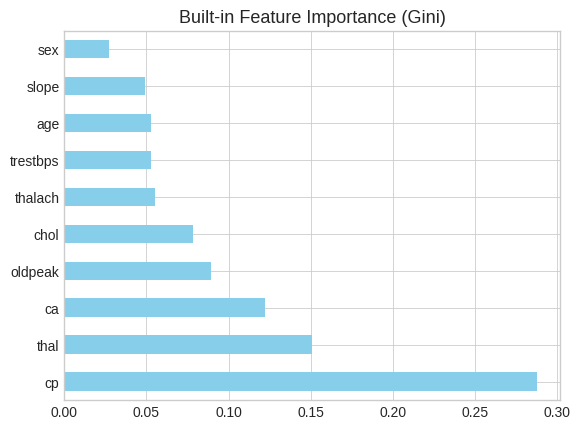

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get feature importance from the trained tree
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

# 2. Plot the top 10
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Built-in Feature Importance (Gini)")
plt.show()

---
## ⚖️Decision Tree vs Random Forest — Summary Comparison

,Decision Tree 🌳,Random Forest 🌲🌲
Aspect,,
Speed,⚡ Fast,🐢 Slower
Interpretability,✅ Easy to visualize & explain,❌ Hard to interpret
Overfitting Tendency,⚠️ High (needs pruning),✅ Low (ensemble reduces it)
Accuracy,📉 Lower (usually),📈 Higher (usually)
Training Data Needed,📦 Small datasets OK,📦 More data benefits
Feature Importance,✅ Yes,✅ Yes (averaged)
Best Use Case,When explainability is crucial,When accuracy matters most


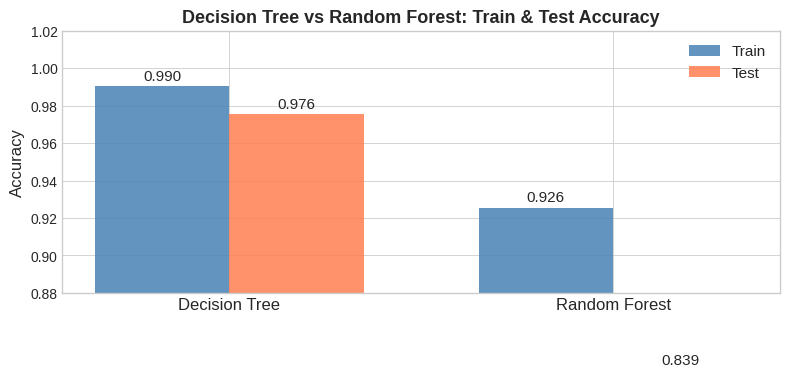

In [42]:
# Side-by-side comparison
comparison_data = {
    'Aspect': [
        'Speed',
        'Interpretability',
        'Overfitting Tendency',
        'Accuracy',
        'Training Data Needed',
        'Feature Importance',
        'Best Use Case'
    ],
    'Decision Tree 🌳': [
        '⚡ Fast',
        '✅ Easy to visualize & explain',
        '⚠️ High (needs pruning)',
        '📉 Lower (usually)',
        '📦 Small datasets OK',
        '✅ Yes',
        'When explainability is crucial'
    ],
    'Random Forest 🌲🌲': [
        '🐢 Slower',
        '❌ Hard to interpret',
        '✅ Low (ensemble reduces it)',
        '📈 Higher (usually)',
        '📦 More data benefits',
        '✅ Yes (averaged)',
        'When accuracy matters most'
    ]
}

comp_df = pd.DataFrame(comparison_data)
display(comp_df.set_index('Aspect'))

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 4))
models = ['Decision Tree', 'Random Forest']
train_accs_comp = [model.score(X_train, y_train), rf_model.score(X_train, y_train)]
test_accs_comp  = [model.score(X_test,  y_test),  rf_model.score(X_test,  y_test)]

x = np.arange(len(models))
w = 0.35
b1 = ax.bar(x - w/2, train_accs_comp, w, label='Train', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, test_accs_comp,  w, label='Test',  color='coral',     alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0.88, 1.02)
ax.set_title('Decision Tree vs Random Forest: Train & Test Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()